# Analise Exploratoria - Deteccao de Anomalias em Campanhas de E-mail Marketing

Visualiza series temporais de `taxa_abertura` e `ctr` para campanhas de exemplo,
sobrepondo tres fontes de sinal:

- **Anomalia real injetada** (gabarito) — o que de fato foi simulado
- **Deteccao via z-score** (por campanha, ver `detect_anomalies_zscore.py`)
- **Deteccao via Isolation Forest** (por campanha, ver `detect_anomalies_ml.py`)

O objetivo e evidenciar visualmente onde os metodos acertam, erram e onde ha
sobreposicao entre eles.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
RAW_DIR = BASE_DIR / "data" / "raw"
OUTPUTS_DIR = BASE_DIR / "outputs"

# Paleta categorica validada (contraste + distincao em daltonismo - CVD), com
# forma de marcador distinta por fonte de deteccao. Cor nunca e o unico canal
# de identidade (ver skill de dataviz do projeto).
COR_LINHA = "#2a78d6"              # azul - valor da metrica
COR_ANOMALIA_REAL = "#e34948"      # vermelho - gabarito (anomalia realmente injetada)
COR_ZSCORE = "#4a3aa7"             # violeta - detectado pelo zscore
COR_ISOLATION_FOREST = "#eb6834"   # laranja - detectado pelo isolation forest

plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["axes.edgecolor"] = "#c3c2b7"
plt.rcParams["axes.labelcolor"] = "#0b0b0b"
plt.rcParams["text.color"] = "#0b0b0b"
plt.rcParams["xtick.color"] = "#52514e"
plt.rcParams["ytick.color"] = "#52514e"
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["font.size"] = 10

In [2]:
agregado = pd.read_csv(PROCESSED_DIR / "fato_agregado_diario.csv", parse_dates=["dat_referencia"])
gabarito = pd.read_csv(RAW_DIR / "gabarito_anomalias.csv")
zscore = pd.read_csv(OUTPUTS_DIR / "anomalias_zscore.csv", parse_dates=["dat_referencia"])
isolation_forest = pd.read_csv(OUTPUTS_DIR / "anomalias_isolation_forest.csv", parse_dates=["dat_referencia"])

print(f"{len(agregado)} disparos agregados, {len(gabarito)} disparos no gabarito.")
print(f"{len(zscore)} linhas de deteccao zscore, {len(isolation_forest)} linhas de deteccao isolation_forest.")

260 disparos agregados, 260 disparos no gabarito.
780 linhas de deteccao zscore, 260 linhas de deteccao isolation_forest.


## Selecionando campanhas de exemplo

Escolhemos as campanhas com maior diversidade de tipos de anomalia injetada no
gabarito (`queda_deliverability`, `clique_bot`, `pico_engajamento`), para
ilustrar os tres cenarios no menor numero de exemplos possivel.

In [3]:
anomalias_reais = gabarito[gabarito["flg_anomalia_injetada"]]
diversidade_por_campanha = (
    anomalias_reais.groupby("id_campanha")["tipo_anomalia_injetada"]
    .nunique()
    .sort_values(ascending=False)
)

campanhas_exemplo = diversidade_por_campanha.head(4).index.tolist()
print("Campanhas de exemplo selecionadas:", campanhas_exemplo)
diversidade_por_campanha.head(4)

Campanhas de exemplo selecionadas: [6, 7, 5, 4]


id_campanha
6    3
7    3
5    3
4    2
Name: tipo_anomalia_injetada, dtype: int64

## Graficos por campanha

Para cada campanha, dois paineis empilhados (`taxa_abertura` e `ctr`) ao longo
dos disparos (`id_disparo`). Marcadores sobrepostos a linha indicam:

- **X vermelho**: anomalia real (gabarito)
- **Triangulo violeta (contorno)**: deteccao z-score
- **Quadrado laranja (contorno)**: deteccao Isolation Forest

Quando os tres simbolos coincidem no mesmo disparo, houve acerto (verdadeiro
positivo). Um X vermelho sem nenhum marcador de metodo ao redor e um falso
negativo; um marcador de metodo sem X vermelho correspondente e um falso
positivo — atencao especial aos disparos de `pico_engajamento`, que sao
anomalias estatisticas "boas" e idealmente nao deveriam ser marcadas como
problema (ver `evaluate.py`).

In [4]:
def plotar_campanha(id_campanha: int) -> None:
    """Plota taxa_abertura e ctr de uma campanha, sobrepondo anomalia real
    (gabarito) e deteccoes de zscore e Isolation Forest."""
    dados = agregado[agregado["id_campanha"] == id_campanha].sort_values("id_disparo")
    dados_por_disparo = dados.set_index("id_disparo")

    gab_campanha = gabarito[gabarito["id_campanha"] == id_campanha]
    z_campanha = zscore[zscore["id_campanha"] == id_campanha]
    if_campanha = isolation_forest[isolation_forest["id_campanha"] == id_campanha]

    metricas = ["taxa_abertura", "ctr"]
    fig, eixos = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    for eixo, metrica in zip(eixos, metricas):
        eixo.plot(
            dados["id_disparo"], dados[metrica],
            color=COR_LINHA, linewidth=2, marker="o", markersize=4,
            label=metrica, zorder=2,
        )

        disparos_reais = gab_campanha.loc[gab_campanha["flg_anomalia_injetada"], "id_disparo"]
        eixo.scatter(
            disparos_reais, dados_por_disparo.loc[disparos_reais, metrica],
            color=COR_ANOMALIA_REAL, marker="X", s=160, linewidths=0,
            label="Anomalia real (gabarito)", zorder=5,
        )

        # zscore avalia cada metrica isoladamente -> filtra por metrica_avaliada.
        disparos_zscore = z_campanha.loc[
            (z_campanha["metrica_avaliada"] == metrica) & z_campanha["flg_anomalia_detectada"],
            "id_disparo",
        ]
        eixo.scatter(
            disparos_zscore, dados_por_disparo.loc[disparos_zscore, metrica],
            facecolors="none", edgecolors=COR_ZSCORE, marker="^", s=180, linewidths=2,
            label="Detectado - zscore", zorder=4,
        )

        # Isolation Forest e multivariado (metrica_avaliada="combinado" para
        # todas as linhas) -> o mesmo flag vale para os dois paineis.
        disparos_if = if_campanha.loc[if_campanha["flg_anomalia_detectada"], "id_disparo"]
        eixo.scatter(
            disparos_if, dados_por_disparo.loc[disparos_if, metrica],
            facecolors="none", edgecolors=COR_ISOLATION_FOREST, marker="s", s=180, linewidths=2,
            label="Detectado - Isolation Forest", zorder=3,
        )

        eixo.set_ylabel(metrica)
        eixo.grid(True, linewidth=0.6)

    eixos[-1].set_xlabel("id_disparo")
    eixos[0].set_title(f"Campanha {id_campanha}")
    eixos[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)

    plt.tight_layout()
    plt.show()

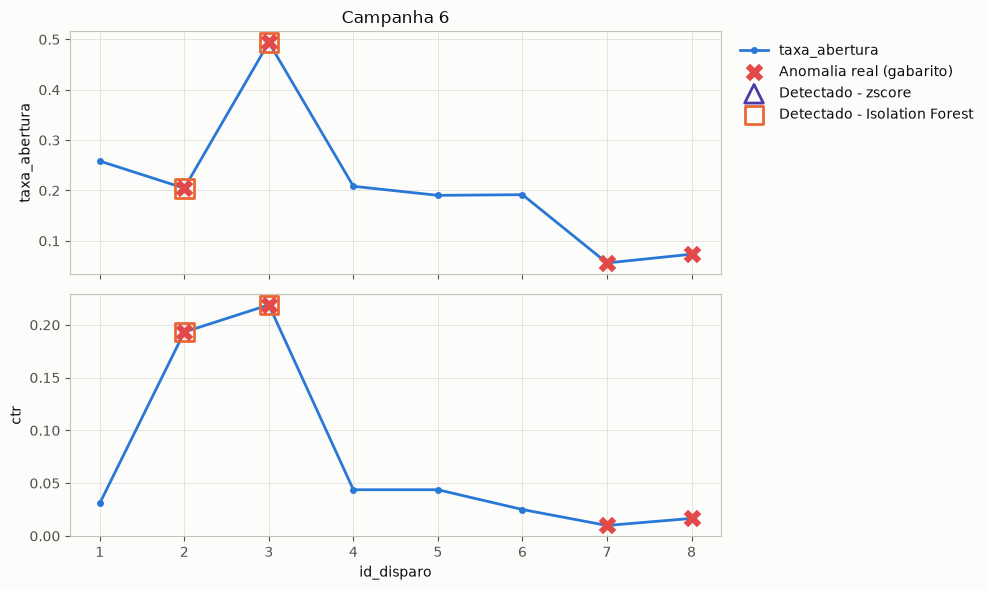

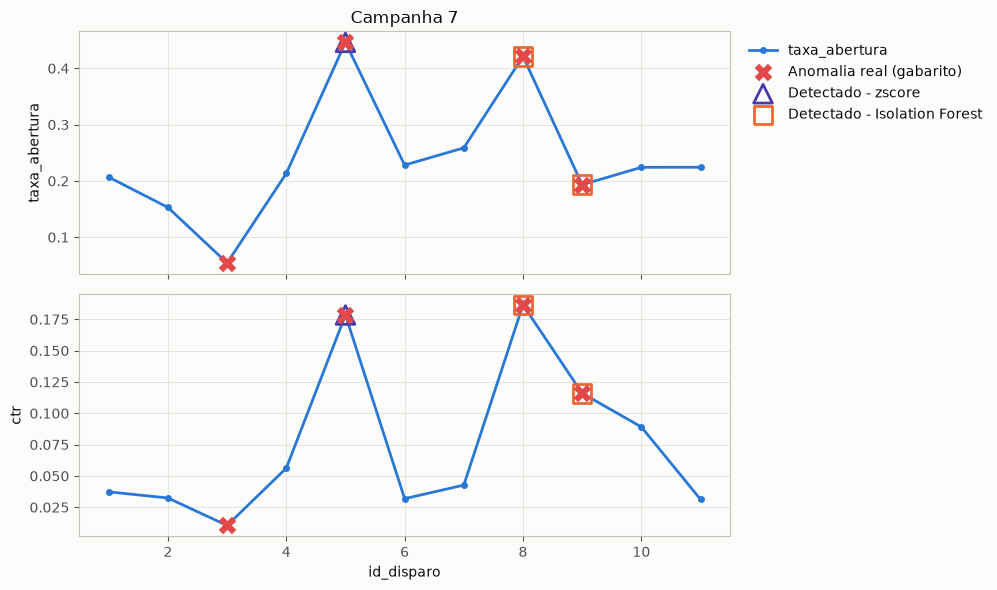

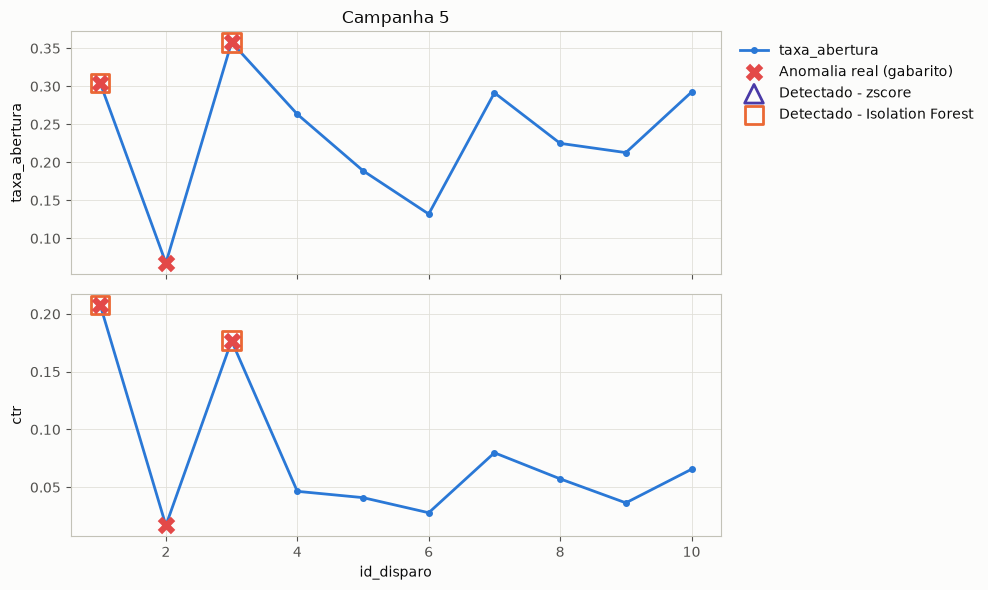

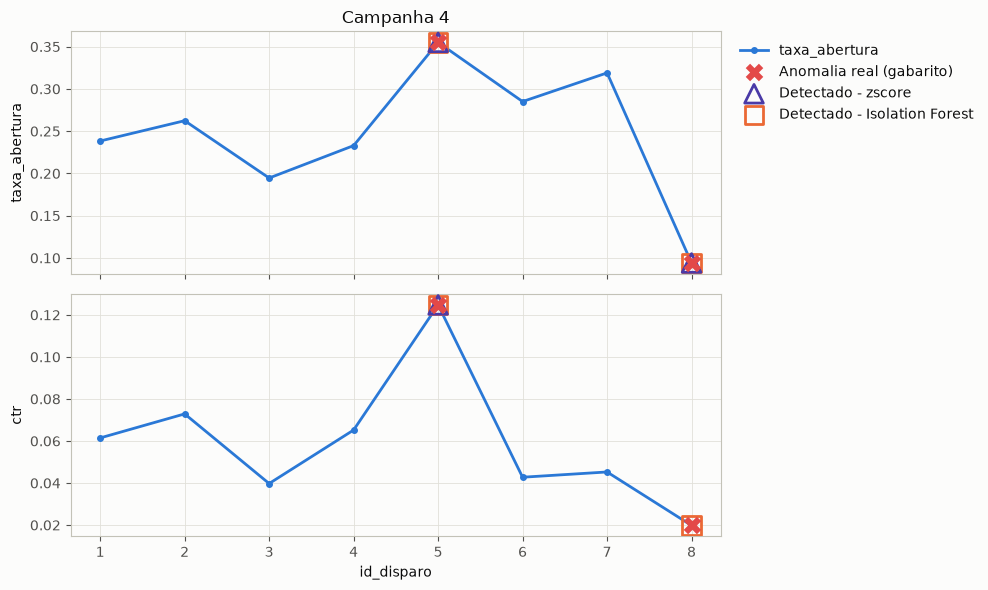

In [5]:
for id_campanha in campanhas_exemplo:
    plotar_campanha(id_campanha)

## Observacoes

- Nas campanhas selecionadas, os disparos de `queda_deliverability` aparecem
  como um vale isolado em `taxa_abertura`, geralmente capturado por ambos os
  metodos.
- Os disparos de `clique_bot` sobem em `ctr` sem uma subida equivalente em
  `taxa_abertura` no mesmo disparo — e o padrao que o Isolation Forest, por
  ser multivariado, tende a capturar melhor que o z-score (ver
  `outputs/comparativo_metodos.csv`).
- Os disparos de `pico_engajamento` sobem em ambas as metricas ao mesmo
  tempo. Repare que, quando marcados por algum metodo, isso e um falso
  alarme esperado no cenario atual — nenhum dos dois detectores usa a
  direcao do desvio, entao um pico bom pode ser confundido com anomalia.